In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

X, y = fetch_openml("titanic", version=1, as_frame=True, return_X_y=True)

df = X.copy()
df['target'] = y

print(df.head())
print(df.shape)
print(df.info())
print(df.describe(include='all'))
print(df['target'].value_counts())

   pclass                                             name     sex      age  \
0       1                    Allen, Miss. Elisabeth Walton  female  29.0000   
1       1                   Allison, Master. Hudson Trevor    male   0.9167   
2       1                     Allison, Miss. Helen Loraine  female   2.0000   
3       1             Allison, Mr. Hudson Joshua Creighton    male  30.0000   
4       1  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female  25.0000   

   sibsp  parch  ticket      fare    cabin embarked boat   body  \
0      0      0   24160  211.3375       B5        S    2    NaN   
1      1      2  113781  151.5500  C22 C26        S   11    NaN   
2      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest target  
0                     St Louis, MO      1  
1  Montreal, PQ / Chesterville, ON

In [2]:
selected_features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

In [3]:
selected_features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

df_model = df[selected_features + ['target']].copy()

print(df_model.head())
print(df_model.info())
print(df_model.isnull().sum())

   pclass     sex      age  sibsp  parch      fare embarked target
0       1  female  29.0000      0      0  211.3375        S      1
1       1    male   0.9167      1      2  151.5500        S      1
2       1  female   2.0000      1      2  151.5500        S      0
3       1    male  30.0000      1      2  151.5500        S      0
4       1  female  25.0000      1      2  151.5500        S      0
<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   int64   
 1   sex       1309 non-null   category
 2   age       1046 non-null   float64 
 3   sibsp     1309 non-null   int64   
 4   parch     1309 non-null   int64   
 5   fare      1308 non-null   float64 
 6   embarked  1307 non-null   category
 7   target    1309 non-null   category
dtypes: category(3), float64(2), int64(3)
memory usage: 55.5 KB
None
pclass        0
sex           0
ag

In [4]:
print(df_model.isnull().sum())

pclass        0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
target        0
dtype: int64


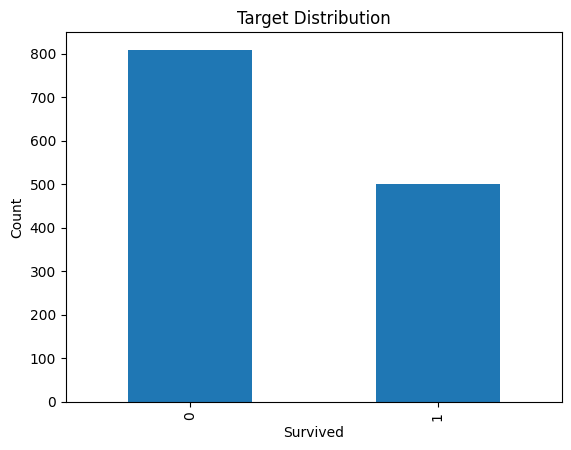

In [5]:
df_model['target'].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

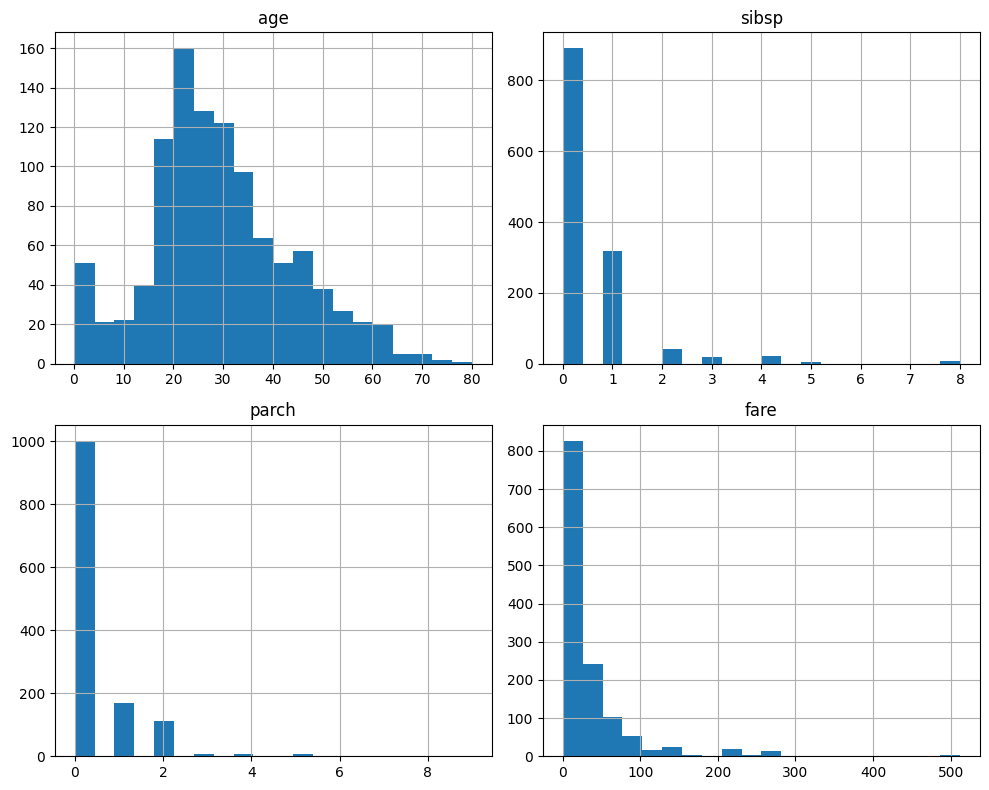

In [6]:
num_cols = ['age', 'sibsp', 'parch', 'fare']
df_model[num_cols].hist(figsize=(10, 8), bins=20)
plt.tight_layout()
plt.show()

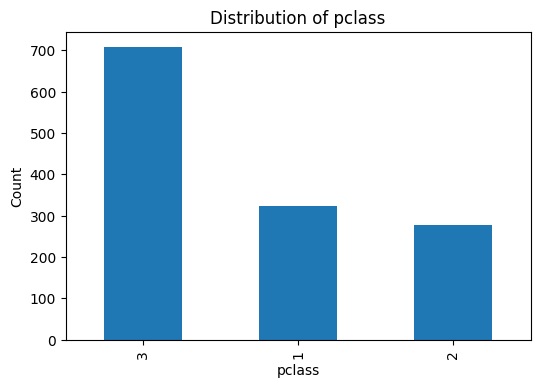

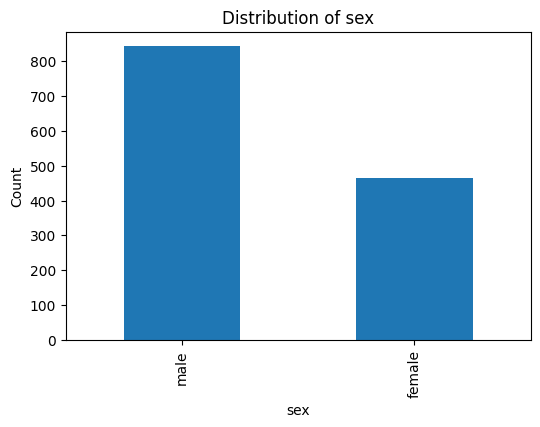

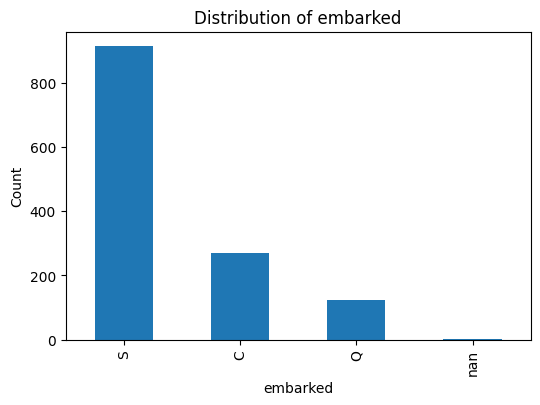

In [7]:
cat_cols = ['pclass', 'sex', 'embarked']

for col in cat_cols:
    plt.figure(figsize=(6, 4))
    df_model[col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

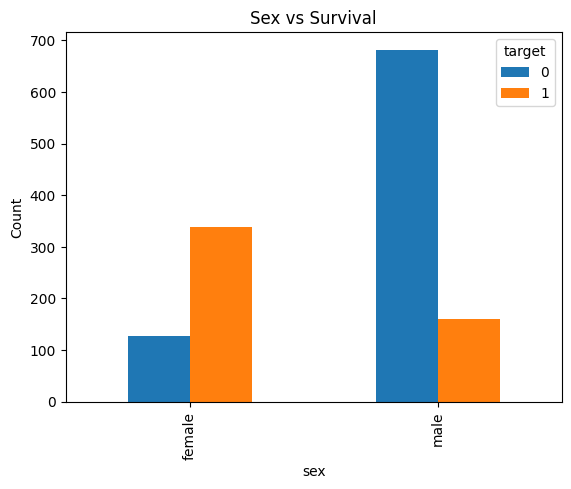

In [8]:
pd.crosstab(df_model['sex'], df_model['target']).plot(kind='bar')
plt.title('Sex vs Survival')
plt.ylabel('Count')
plt.show()

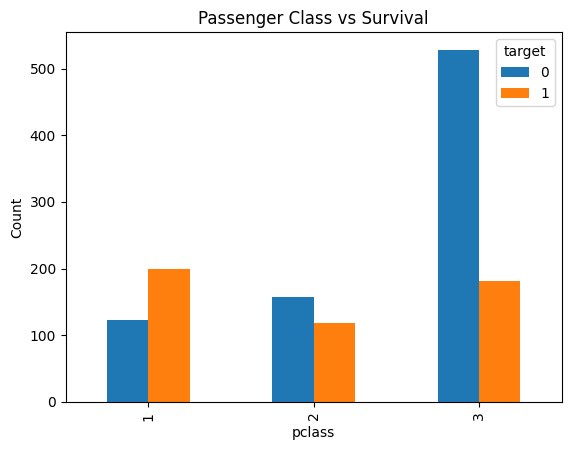

In [9]:
pd.crosstab(df_model['pclass'], df_model['target']).plot(kind='bar')
plt.title('Passenger Class vs Survival')
plt.ylabel('Count')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = df_model.drop(columns=['target'])
y = df_model['target']

numeric_features = ['age', 'sibsp', 'parch', 'fare']
categorical_features = ['pclass', 'sex', 'embarked']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Accuracy: 0.8053435114503816
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       162
           1       0.76      0.71      0.74       100

    accuracy                           0.81       262
   macro avg       0.80      0.79      0.79       262
weighted avg       0.80      0.81      0.80       262



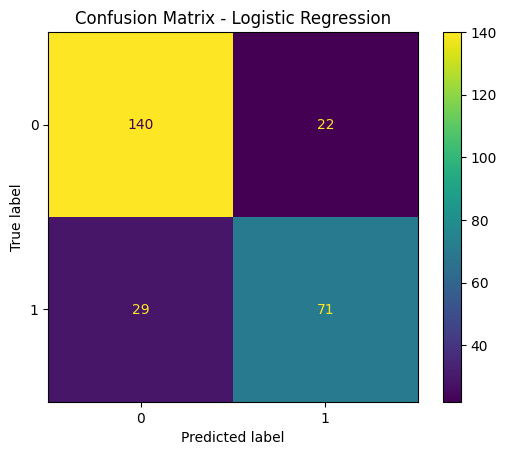

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=2000))
])

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Accuracy: 0.8320610687022901
              precision    recall  f1-score   support

           0       0.82      0.94      0.87       162
           1       0.87      0.66      0.75       100

    accuracy                           0.83       262
   macro avg       0.84      0.80      0.81       262
weighted avg       0.84      0.83      0.83       262



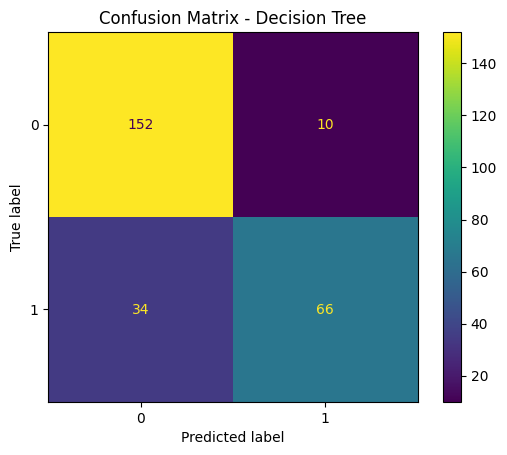

In [16]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
])

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)
plt.title("Confusion Matrix - Decision Tree")
plt.show()

Accuracy: 0.7862595419847328
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       162
           1       0.72      0.72      0.72       100

    accuracy                           0.79       262
   macro avg       0.77      0.77      0.77       262
weighted avg       0.79      0.79      0.79       262



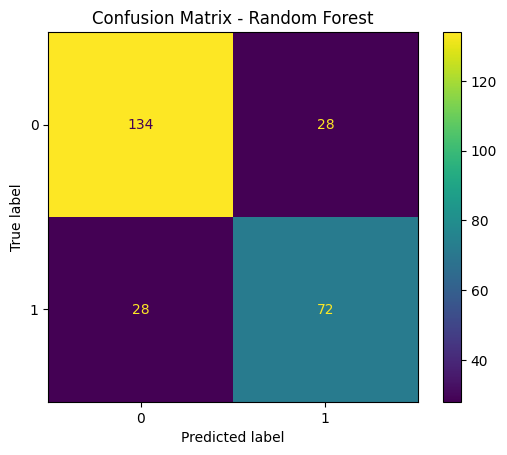

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [18]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.805344
1        Decision Tree  0.832061
2        Random Forest  0.786260


Titanic dataset is a binary classification problem with both numeric and categorical features. A subset of structured features was selected for the beginner-level model, while complex text-heavy columns were excluded. Missing values were found in columns such as age and embarked, so imputation was required. Numeric features were scaled, and categorical features were one-hot encoded using a preprocessing pipeline. EDA suggested that features such as sex and passenger class were strongly related to survival. Logistic Regression, Decision Tree, and Random Forest were trained and compared using classification metrics and confusion matrices
